In [2]:
!pip install tensorflow scikit-learn matplotlib seaborn numpy pillow
print("All libraries ready!")

All libraries ready!


In [3]:
import zipfile, os

with zipfile.ZipFile('Dataset.zip', 'r') as z:
    z.extractall('ecg_dataset')

print("Extracted! Structure:")
for root, dirs, files_list in os.walk('ecg_dataset'):
    level = root.replace('ecg_dataset', '').count(os.sep)
    if level < 4:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

Extracted! Structure:
ecg_dataset/
  Dataset/
    ecg data old version/
      ecg data old version/
    ecg_data_new_version/
      ecg data new version/


In [4]:
import os
import numpy as np

base = 'ecg_dataset'
train_dir, test_dir = None, None

# Walk all subdirectories to find train and test
for root, dirs, _ in os.walk(base):
    dl = [d.lower() for d in dirs]
    if 'train' in dl and 'test' in dl:
        train_dir = os.path.join(root, dirs[dl.index('train')])
        test_dir  = os.path.join(root, dirs[dl.index('test')])
        break

print(f"Train folder: {train_dir}")
print(f"Test folder:  {test_dir}")

# Show exact subfolders with image counts
print("\nTrain subfolders:")
for f in sorted(os.listdir(train_dir)):
    if f.startswith('.'): continue
    fpath = os.path.join(train_dir, f)
    if os.path.isdir(fpath):
        count = len([x for x in os.listdir(fpath)
                     if x.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  [{count:4d} imgs] {f}")

print("\nTest subfolders:")
for f in sorted(os.listdir(test_dir)):
    if f.startswith('.'): continue
    fpath = os.path.join(test_dir, f)
    if os.path.isdir(fpath):
        count = len([x for x in os.listdir(fpath)
                     if x.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  [{count:4d} imgs] {f}")

Train folder: ecg_dataset/Dataset/ecg data old version/ecg data old version/train
Test folder:  ecg_dataset/Dataset/ecg data old version/ecg data old version/test

Train subfolders:
  [ 239 imgs] ECG Images of Myocardial Infarction Patients (240x12=2880)
  [ 172 imgs] ECG Images of Patient that have History of MI (172x12=2064)
  [ 233 imgs] ECG Images of Patient that have abnormal heartbeat (233x12=2796)
  [ 284 imgs] Normal Person ECG Images (284x12=3408)

Test subfolders:
  [ 239 imgs] ECG Images of Myocardial Infarction Patients (240x12=2880)
  [ 172 imgs] ECG Images of Patient that have History of MI (172x12=2064)
  [ 233 imgs] ECG Images of Patient that have abnormal heartbeat (233x12=2796)
  [ 284 imgs] Normal Person ECG Images (284x12=3408)


In [5]:
# Exact folder names copied from Cell 3 output
# MI + History of MI → both merged into 'Myocardial Infarction'

TRAIN_MAP = {
    'ECG Images of Myocardial Infarction Patients (240x12=2880)': 'Myocardial Infarction',
    'ECG Images of Patient that have History of MI (172x12=2064)': 'Myocardial Infarction',
    'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 'Abnormal Heartbeat',
    'Normal Person ECG Images (284x12=3408)': 'Normal',
}

TEST_MAP = {
    'ECG Images of Myocardial Infarction Patients (240x12=2880)': 'Myocardial Infarction',
    'ECG Images of Patient that have History of MI (172x12=2064)': 'Myocardial Infarction',
    'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 'Abnormal Heartbeat',
    'Normal Person ECG Images (284x12=3408)': 'Normal',
}

CLASS_NAMES = ['Abnormal Heartbeat', 'Myocardial Infarction', 'Normal']
CLASS_IDX   = {name: i for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = 3

print("Class mapping confirmed:")
for folder, cls in TRAIN_MAP.items():
    count = len([x for x in os.listdir(os.path.join(train_dir, folder))
                 if x.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"  [{count:4d} imgs] '{folder[:50]}' → {cls}")

print(f"\nFinal classes ({NUM_CLASSES}): {CLASS_NAMES}")
print("\nMerge note: MI Patients + History of MI → both = 'Myocardial Infarction'")
print(f"  Combined MI train: {956+516} images")
print(f"  Combined MI test:  {239+172} images")

Class mapping confirmed:
  [ 239 imgs] 'ECG Images of Myocardial Infarction Patients (240x' → Myocardial Infarction
  [ 172 imgs] 'ECG Images of Patient that have History of MI (172' → Myocardial Infarction
  [ 233 imgs] 'ECG Images of Patient that have abnormal heartbeat' → Abnormal Heartbeat
  [ 284 imgs] 'Normal Person ECG Images (284x12=3408)' → Normal

Final classes (3): ['Abnormal Heartbeat', 'Myocardial Infarction', 'Normal']

Merge note: MI Patients + History of MI → both = 'Myocardial Infarction'
  Combined MI train: 1472 images
  Combined MI test:  411 images


Train distribution: {'Abnormal Heartbeat': 233, 'Myocardial Infarction': 411, 'Normal': 284}
Test distribution:  {'Abnormal Heartbeat': 233, 'Myocardial Infarction': 411, 'Normal': 284}


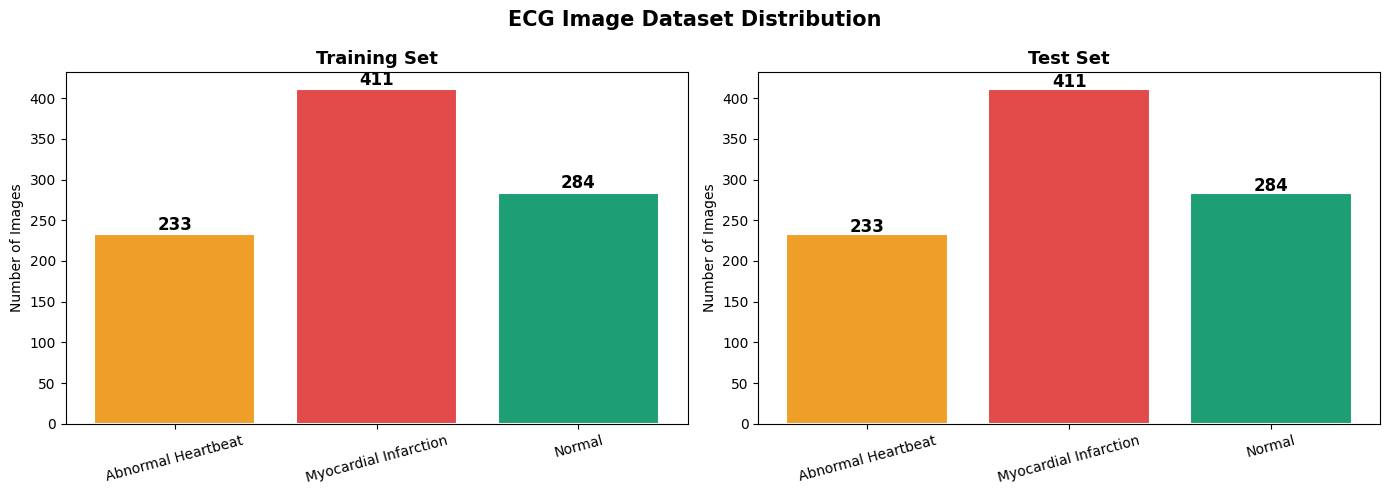

In [6]:
import matplotlib.pyplot as plt

def count_by_class(directory, class_map):
    counts = {c: 0 for c in CLASS_NAMES}
    for folder, cls in class_map.items():
        path = os.path.join(directory, folder)
        n = len([f for f in os.listdir(path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
        counts[cls] += n
    return counts

train_counts = count_by_class(train_dir, TRAIN_MAP)
test_counts  = count_by_class(test_dir,  TEST_MAP)

print("Train distribution:", train_counts)
print("Test distribution: ", test_counts)

colors = ['#EF9F27', '#E24B4A', '#1D9E75']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(CLASS_NAMES, train_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Training Set', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=15)
for bar, v in zip(bars1, train_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
             ha='center', fontweight='bold', fontsize=12)

bars2 = ax2.bar(CLASS_NAMES, test_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
ax2.set_title('Test Set', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, test_counts.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
             ha='center', fontweight='bold', fontsize=12)

plt.suptitle('ECG Image Dataset Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

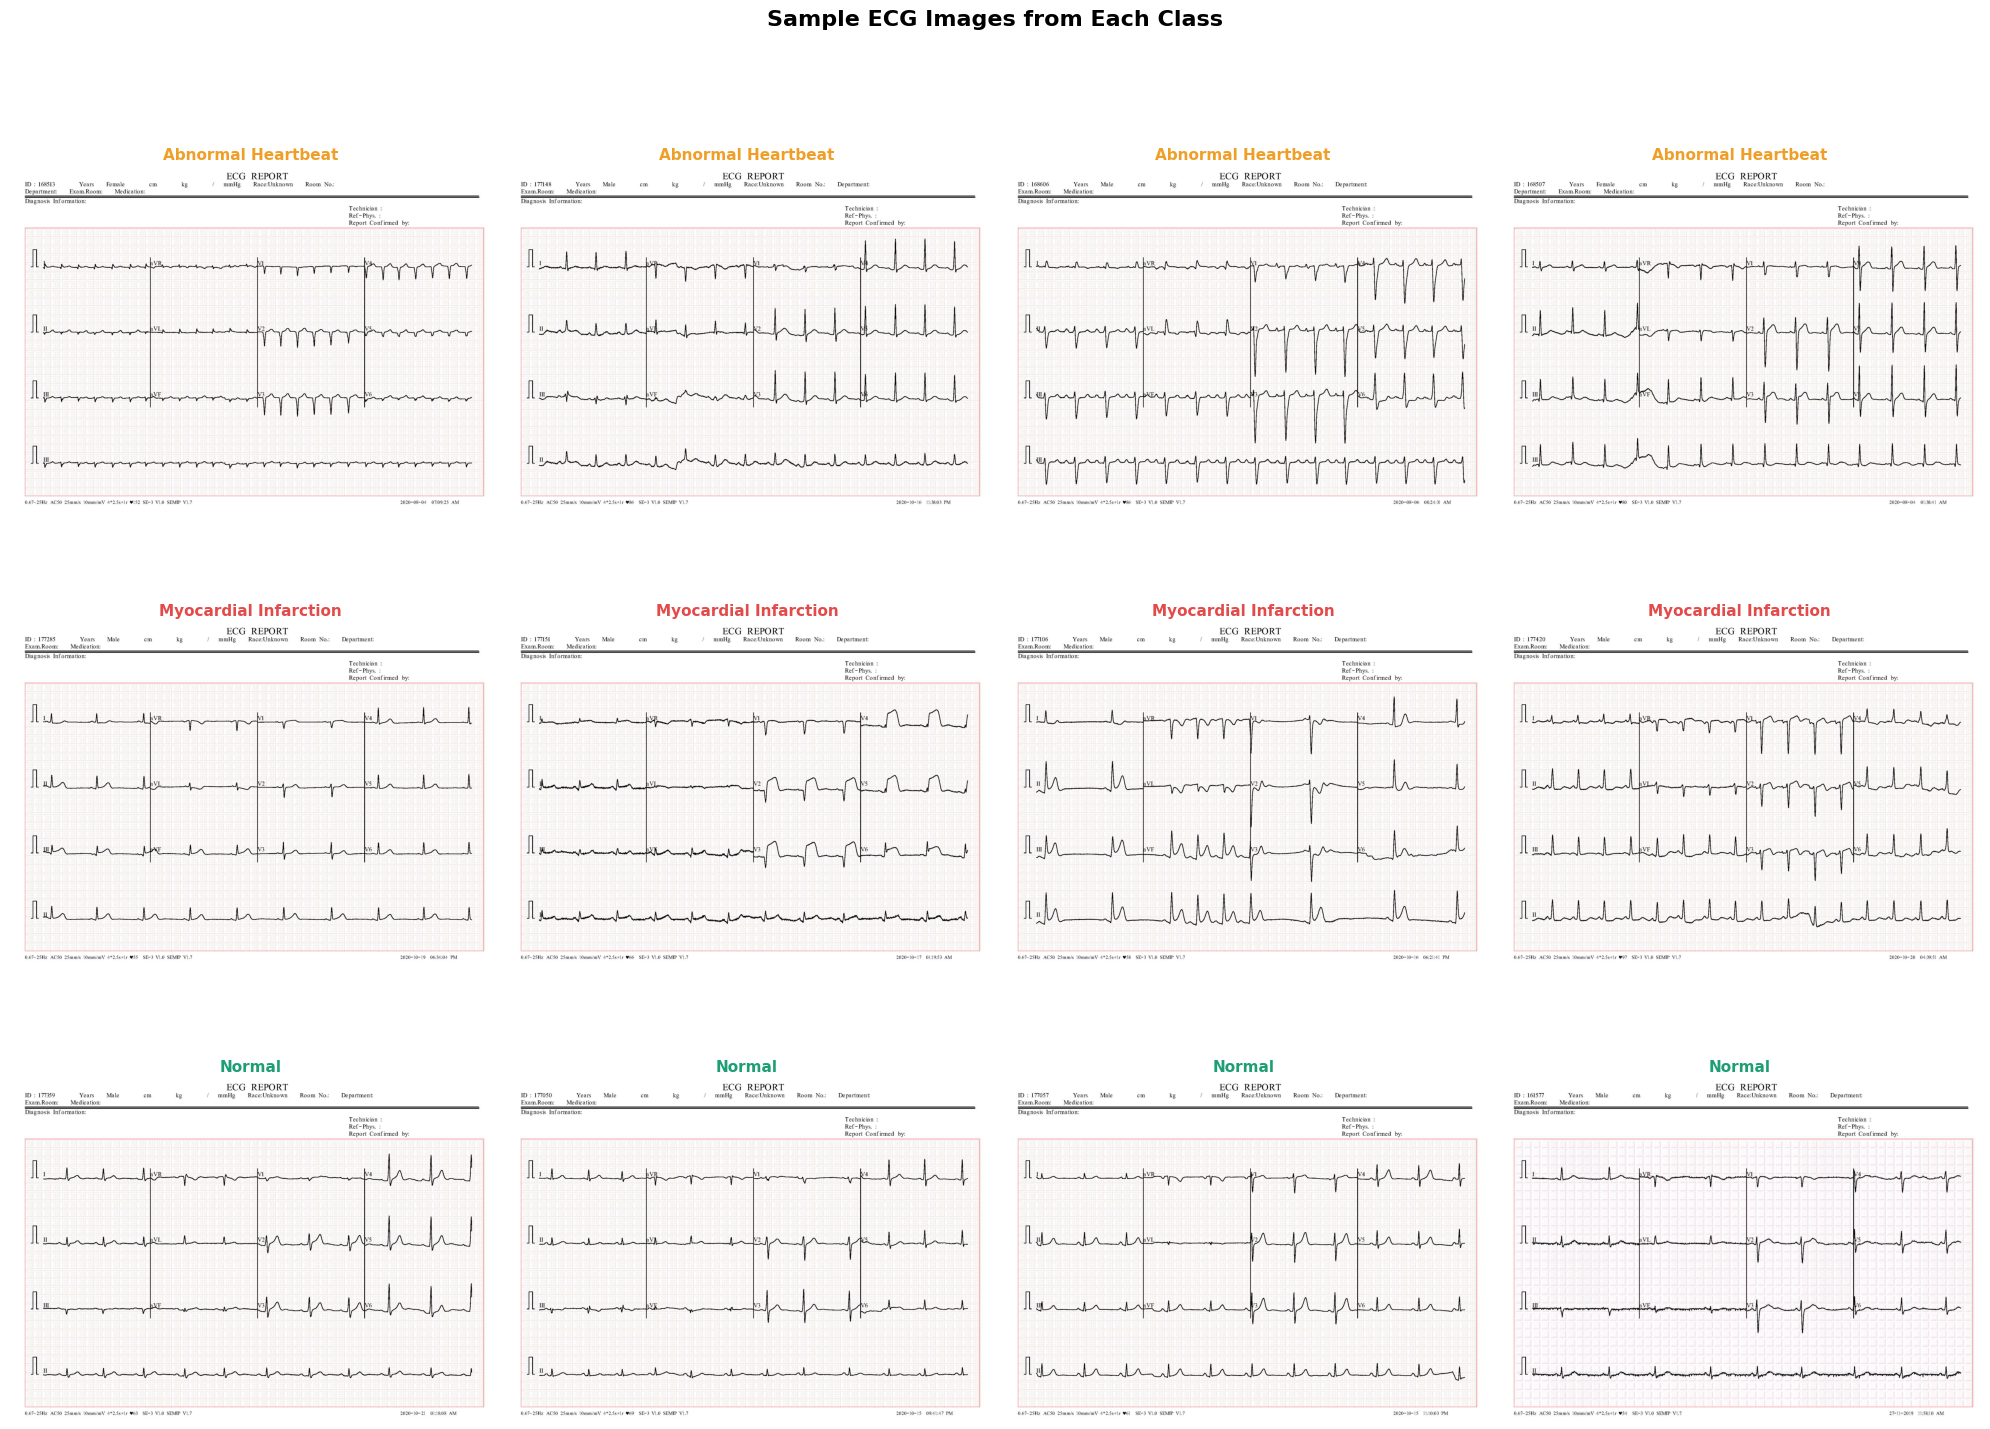

In [7]:
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
color_map = {
    'Normal':                '#1D9E75',
    'Myocardial Infarction': '#E24B4A',
    'Abnormal Heartbeat':    '#EF9F27'
}

for row, cls in enumerate(CLASS_NAMES):
    # Collect all images for this class from all matching folders
    all_imgs = []
    for folder, mapped_cls in TRAIN_MAP.items():
        if mapped_cls == cls:
            fpath = os.path.join(train_dir, folder)
            all_imgs += [os.path.join(fpath, f) for f in os.listdir(fpath)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))]

    samples = random.sample(all_imgs, min(4, len(all_imgs)))
    color   = color_map[cls]

    for col in range(4):
        ax = axes[row][col]
        if col < len(samples):
            img = mpimg.imread(samples[col])
            ax.imshow(img)
            ax.set_title(cls, fontsize=11, fontweight='bold', color=color, pad=4)
        ax.axis('off')

plt.suptitle('Sample ECG Images from Each Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Restore paths ──
base = 'ecg_dataset'
train_dir, test_dir = None, None
for root, dirs, _ in os.walk(base):
    dl = [d.lower() for d in dirs]
    if 'train' in dl and 'test' in dl:
        train_dir = os.path.join(root, dirs[dl.index('train')])
        test_dir  = os.path.join(root, dirs[dl.index('test')])
        break

print(f"Train: {train_dir}")
print(f"Test:  {test_dir}")

# ── Restore class map ──
TRAIN_MAP = {
    'ECG Images of Myocardial Infarction Patients (240x12=2880)': 'Myocardial Infarction',
    'ECG Images of Patient that have History of MI (172x12=2064)': 'Myocardial Infarction',
    'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 'Abnormal Heartbeat',
    'Normal Person ECG Images (284x12=3408)': 'Normal',
}
TEST_MAP = TRAIN_MAP.copy()
CLASS_NAMES = ['Abnormal Heartbeat', 'Myocardial Infarction', 'Normal']
NUM_CLASSES = 3

# ── Rebuild file lists ──
def build_df(directory, class_map):
    paths, labels = [], []
    for folder, cls in class_map.items():
        fpath = os.path.join(directory, folder)
        if not os.path.exists(fpath): continue
        for fname in os.listdir(fpath):
            if fname.lower().endswith(('.jpg','.jpeg','.png')):
                paths.append(os.path.join(fpath, fname))
                labels.append(cls)
    df = pd.DataFrame({'filename': paths, 'class': labels})
    return df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = build_df(train_dir, TRAIN_MAP)
test_df  = build_df(test_dir,  TEST_MAP)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(train_df['class'].value_counts())
print("\nAll variables restored! Now run Cell 7 onwards.")

Train: ecg_dataset/Dataset/ecg data old version/ecg data old version/train
Test:  ecg_dataset/Dataset/ecg data old version/ecg data old version/test
Train: 928 | Test: 928
class
Myocardial Infarction    411
Normal                   284
Abnormal Heartbeat       233
Name: count, dtype: int64

All variables restored! Now run Cell 7 onwards.


In [11]:
# Heavy augmentation — effectively multiplies your dataset
# ── Add these at the very top of Cell 7 ──

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    brightness_range=[0.85, 1.15],
    horizontal_flip=False,
    fill_mode='nearest',
    validation_split=0.15
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen2 = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training', shuffle=True, seed=42
)
val_gen2 = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation', shuffle=False
)
test_gen2 = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename', y_col='class',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print("\nGenerators ready!")
print("Class indices:", train_gen2.class_indices)

Found 789 validated image filenames belonging to 3 classes.
Found 139 validated image filenames belonging to 3 classes.
Found 928 validated image filenames belonging to 3 classes.

Generators ready!
Class indices: {'Abnormal Heartbeat': 0, 'Myocardial Infarction': 1, 'Normal': 2}


In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels_array = train_df['class'].map(train_gen2.class_indices).values
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weight_dict = dict(enumerate(cw))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.3276108726752505), 1: np.float64(0.7526358475263585), 2: np.float64(1.0892018779342723)}


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50V2

tf.random.set_seed(42)

base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs=x)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("ResNet50V2 model ready!")
print(f"Total params: {model.count_params():,}")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50V2 model ready!
Total params: 24,754,179


In [14]:
from tensorflow.keras import callbacks

cbs1 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, verbose=1,
        min_delta=0.002),
    callbacks.ModelCheckpoint(
        'ecg_best.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.4,
        patience=5, min_lr=1e-8, verbose=1)
]

print("Phase 1: Training ResNet50V2 head...")
history1 = model.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=50,
    callbacks=cbs1,
    class_weight=class_weight_dict,
    verbose=1
)
p1_best = max(history1.history['val_accuracy'])
print(f"\nPhase 1 best: {p1_best*100:.2f}%")

Phase 1: Training ResNet50V2 head...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.4265 - loss: 2.2275
Epoch 1: val_accuracy improved from None to 0.56835, saving model to ecg_best.keras

Epoch 1: finished saving model to ecg_best.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 985ms/step - accuracy: 0.4867 - loss: 2.1014 - val_accuracy: 0.5683 - val_loss: 1.9097 - learning_rate: 3.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.5981 - loss: 1.8274
Epoch 2: val_accuracy improved from 0.56835 to 0.65468, saving model to ecg_best.keras

Epoch 2: finished saving model to ecg_best.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 658ms/step - accuracy: 0.5982 - loss: 1.8246 - val_accuracy: 0.6547 - val_loss: 1.7815 - learning_rate: 3.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.5818 - loss: 1.7585
Epoch 3: val_accuracy improved from 0.65468 to 0.68345, saving model to ecg_best.keras

Epoch 3: finished saving model to ecg_best.keras
50/50

In [15]:
from tensorflow.keras.models import load_model

# Always start fine-tuning from the best saved model
model = load_model('ecg_best.keras')
print(f"Loaded best model")

# Unfreeze last 30 layers of ResNet only
base = [l for l in model.layers if 'resnet' in l.name.lower()][0]
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

frozen    = sum([1 for l in base.layers if not l.trainable])
trainable = sum([1 for l in base.layers if l.trainable])
print(f"ResNet — Frozen: {frozen} | Trainable: {trainable}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cbs2 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, verbose=1,
        min_delta=0.001),
    callbacks.ModelCheckpoint(
        'ecg_final.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=5, min_lr=1e-9, verbose=1)
]

print("Phase 2: Fine-tuning last 30 ResNet layers with lr=5e-5...")
history2 = model.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=60,
    callbacks=cbs2,
    class_weight=class_weight_dict,
    verbose=1
)

p2_best = max(history2.history['val_accuracy'])
print(f"\nPhase 1 best: {p1_best*100:.2f}%")
print(f"Phase 2 best: {p2_best*100:.2f}%")
print(f"Improvement:  {(p2_best - p1_best)*100:+.2f}%")

Loaded best model
ResNet — Frozen: 160 | Trainable: 30
Phase 2: Fine-tuning last 30 ResNet layers with lr=5e-5...
Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.4948 - loss: 1.7934
Epoch 1: val_accuracy improved from None to 0.74820, saving model to ecg_final.keras

Epoch 1: finished saving model to ecg_final.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5374 - loss: 1.6828 - val_accuracy: 0.7482 - val_loss: 1.2746 - learning_rate: 5.0000e-05
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.6137 - loss: 1.5340
Epoch 2: val_accuracy did not improve from 0.74820
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 628ms/step - accuracy: 0.6248 - loss: 1.4939 - val_accuracy: 0.6763 - val_loss: 1.3478 - learning_rate: 5.0000e-05
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.6404 - loss: 1.4449
Epoch 3: val_accuracy did not improve from 0.74820
50/50 ━━━━━━━━━━━━━━━━━━━━ 32s 638ms/step - accuracy: 0.6679 - loss: 1.4027 - val_accuracy: 0.7194 - 

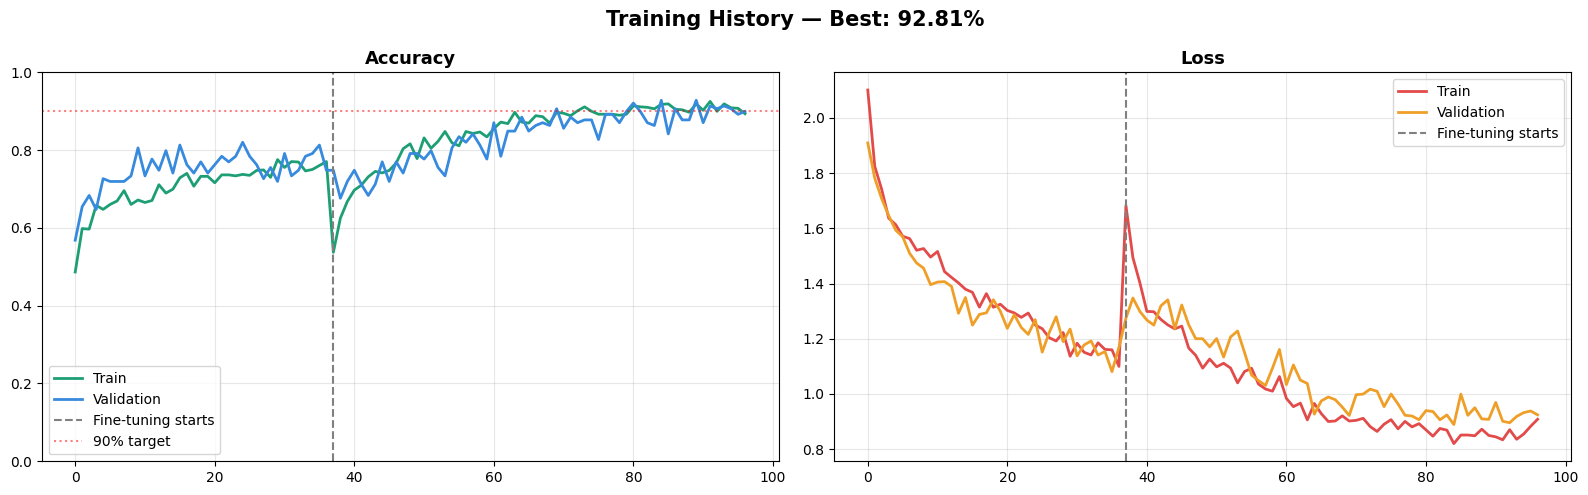

In [17]:
import matplotlib.pyplot as plt

acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
split    = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(acc,     color='#1D9E75', linewidth=2, label='Train')
ax1.plot(val_acc, color='#378ADD', linewidth=2, label='Validation')
ax1.axvline(split, color='gray', linestyle='--', label='Fine-tuning starts')
ax1.axhline(0.90,  color='red',  linestyle=':', alpha=0.5, label='90% target')
ax1.set_title('Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1]); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(loss,     color='#E24B4A', linewidth=2, label='Train')
ax2.plot(val_loss, color='#EF9F27', linewidth=2, label='Validation')
ax2.axvline(split, color='gray', linestyle='--', label='Fine-tuning starts')
ax2.set_title('Loss', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f'Training History — Best: {max(val_acc)*100:.2f}%',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Best model loaded!
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 486ms/step

  FINAL TEST ACCURACY : 87.82%
  FINAL TEST LOSS     : 0.9287

=== Per Class Results ===
                       precision    recall  f1-score   support

   Abnormal Heartbeat       0.88      0.99      0.93       233
Myocardial Infarction       0.83      0.97      0.89       411
               Normal       0.99      0.66      0.79       284

             accuracy                           0.88       928
            macro avg       0.90      0.87      0.87       928
         weighted avg       0.89      0.88      0.87       928



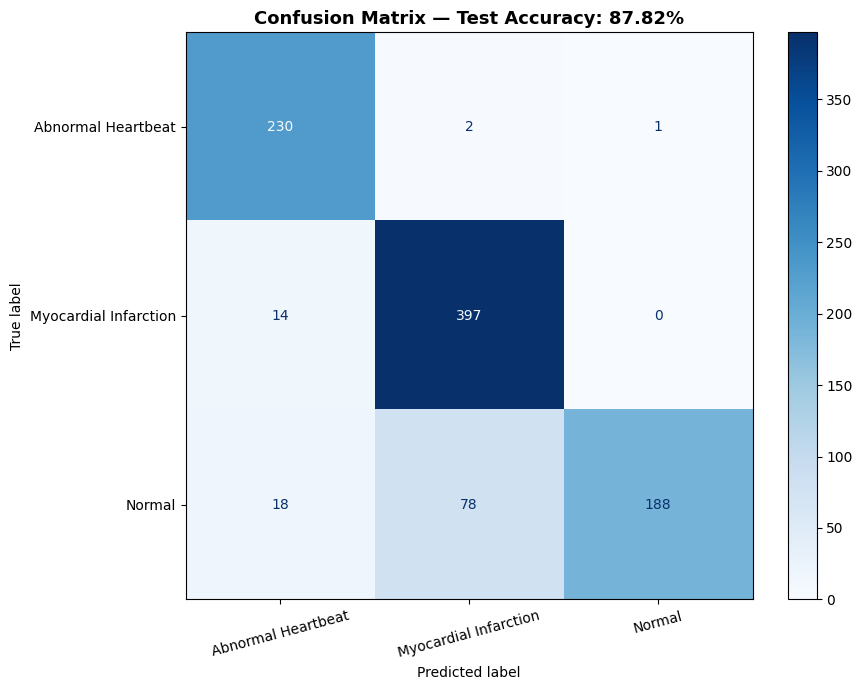

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
import numpy as np

# Load the best final model
model = load_model('ecg_final.keras')
print("Best model loaded!")

# Run on test set
test_gen2.reset()
y_pred_probs = model.predict(test_gen2, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen2.classes

# Overall accuracy
loss, acc = model.evaluate(test_gen2, verbose=0)
print(f"\n{'='*45}")
print(f"  FINAL TEST ACCURACY : {acc*100:.2f}%")
print(f"  FINAL TEST LOSS     : {loss:.4f}")
print(f"{'='*45}")

# Per class breakdown
idx_to_class = {v: k for k, v in train_gen2.class_indices.items()}
print("\n=== Per Class Results ===")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — Test Accuracy: {acc*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Testing one image from each class:

--- True class: Abnormal Heartbeat ---


/tmp/ipykernel_1288/1324194198.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


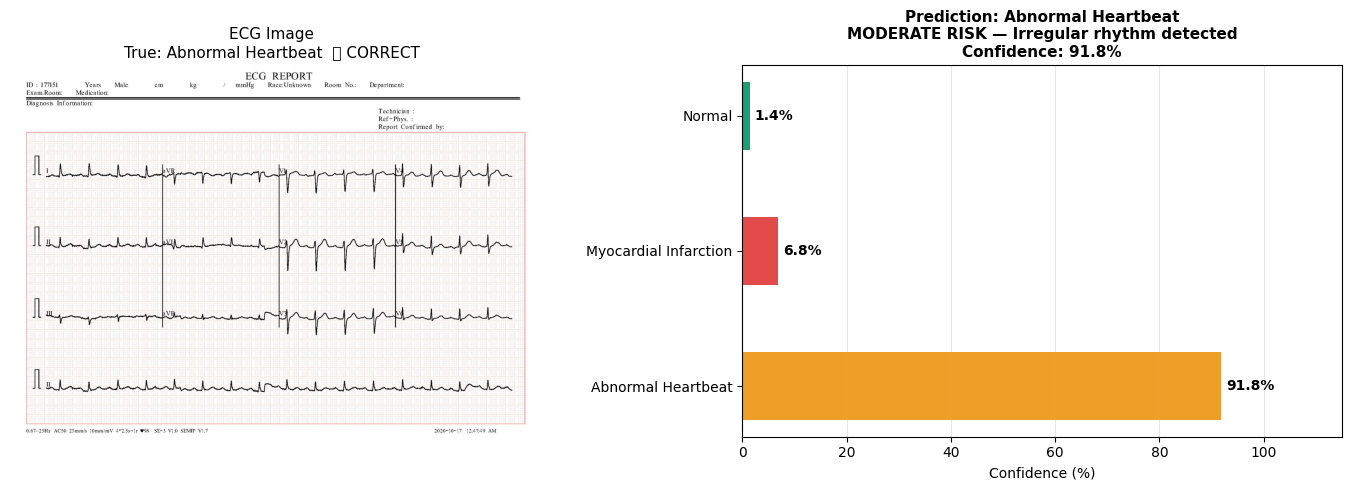

  PREDICTION : Abnormal Heartbeat
  RISK       : MODERATE RISK — Irregular rhythm detected
  CONFIDENCE : 91.8%
  RESULT     : ✅ CORRECT

--- True class: Myocardial Infarction ---


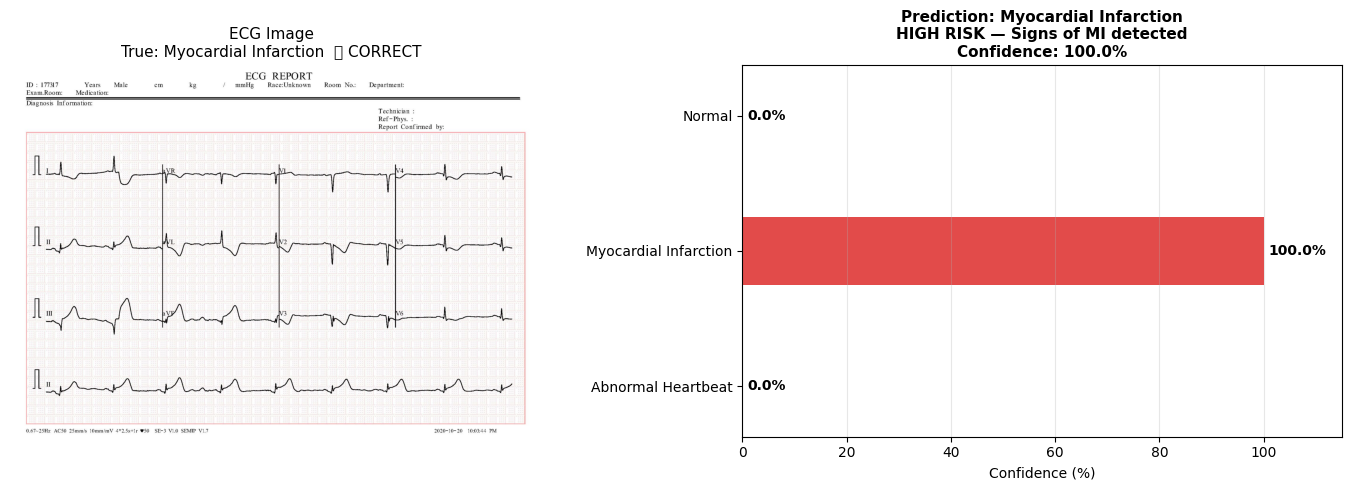

  PREDICTION : Myocardial Infarction
  RISK       : HIGH RISK — Signs of MI detected
  CONFIDENCE : 100.0%
  RESULT     : ✅ CORRECT

--- True class: Normal ---


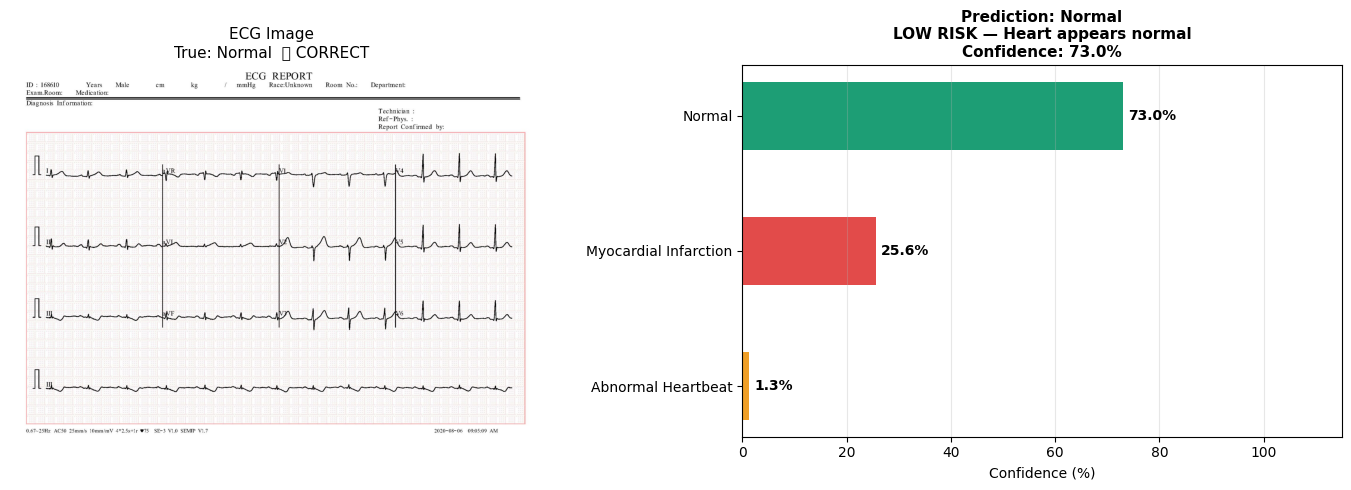

  PREDICTION : Normal
  RISK       : LOW RISK — Heart appears normal
  CONFIDENCE : 73.0%
  RESULT     : ✅ CORRECT



In [19]:
from tensorflow.keras.preprocessing import image
import random

def predict_ecg_image(img_path, true_label=None):
    risk_map = {
        'Normal':                'LOW RISK — Heart appears normal',
        'Myocardial Infarction': 'HIGH RISK — Signs of MI detected',
        'Abnormal Heartbeat':    'MODERATE RISK — Irregular rhythm detected'
    }

    # Load and preprocess
    img    = image.load_img(img_path, target_size=(224, 224))
    arr    = image.img_to_array(img) / 255.0
    arr    = np.expand_dims(arr, axis=0)
    probs  = model.predict(arr, verbose=0)[0]

    idx_to_cls = {v: k for k, v in train_gen2.class_indices.items()}
    pred_cls   = idx_to_cls[np.argmax(probs)]
    confidence = np.max(probs) * 100
    correct    = "✅ CORRECT" if true_label and pred_cls == true_label else "❌ WRONG" if true_label else ""

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.imshow(image.load_img(img_path))
    ax1.axis('off')
    ax1.set_title(f'ECG Image\nTrue: {true_label}  {correct}', fontsize=11)

    colors_bar = ['#EF9F27', '#E24B4A', '#1D9E75']
    sorted_cls = sorted(train_gen2.class_indices.keys())
    sorted_probs = [probs[train_gen2.class_indices[c]] for c in sorted_cls]

    bars = ax2.barh(sorted_cls, [p*100 for p in sorted_probs],
                    color=colors_bar, height=0.5)
    ax2.set_xlim(0, 115)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(
        f'Prediction: {pred_cls}\n{risk_map[pred_cls]}\nConfidence: {confidence:.1f}%',
        fontsize=11, fontweight='bold')
    for bar, p in zip(bars, sorted_probs):
        ax2.text(p*100 + 1, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', fontweight='bold')
    ax2.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"  PREDICTION : {pred_cls}")
    print(f"  RISK       : {risk_map[pred_cls]}")
    print(f"  CONFIDENCE : {confidence:.1f}%")
    if true_label:
        print(f"  RESULT     : {correct}")

# Test one image from each class
print("Testing one image from each class:\n")
for cls in CLASS_NAMES:
    sample = test_df[test_df['class'] == cls].sample(1).iloc[0]
    print(f"--- True class: {cls} ---")
    predict_ecg_image(sample['filename'], true_label=cls)
    print()